# Emilio León
## Ejercicio Predilección de Carreras

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn import tree

In [25]:
df = pd.read_csv("InfoAlus-1.csv")
df.head()

,Unnamed: 0,Gusto_por_Matematicas,Gusto_por_Lectura,Interes_en_IA,Habilidad_Habla_Publica,Pensamiento_Analitico,Interes_en_Asuntos_Globales,Habilidad_Resolucion_Problemas,Promedio_Prepa,Puntos_Examen_Admision,Velocidad_Lectura,Carrera
0,0,3,6,2,6,8,6,3,3,3,7,Relaciones Internacionales
1,1,3,9,3,10,5,7,10,4,1,3,Relaciones Internacionales
2,2,7,7,9,2,8,1,8,1,8,8,Ingeniería en Inteligencia Artificial
3,3,2,9,6,6,9,5,6,7,2,8,Derecho
4,4,4,10,1,4,1,10,6,8,2,1,Relaciones Internacionales


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Unnamed: 0                      100 non-null    int64 
 1   Gusto_por_Matematicas           100 non-null    int64 
 2   Gusto_por_Lectura               100 non-null    int64 
 3   Interes_en_IA                   100 non-null    int64 
 4   Habilidad_Habla_Publica         100 non-null    int64 
 5   Pensamiento_Analitico           100 non-null    int64 
 6   Interes_en_Asuntos_Globales     100 non-null    int64 
 7   Habilidad_Resolucion_Problemas  100 non-null    int64 
 8   Promedio_Prepa                  100 non-null    int64 
 9   Puntos_Examen_Admision          100 non-null    int64 
 10  Velocidad_Lectura               100 non-null    int64 
 11  Carrera                         100 non-null    object
dtypes: int64(11), object(1)
memory usage: 9.5+ KB


In [27]:
df = df.drop(df.columns[0], axis=1)

In [28]:
df.head()

,Gusto_por_Matematicas,Gusto_por_Lectura,Interes_en_IA,Habilidad_Habla_Publica,Pensamiento_Analitico,Interes_en_Asuntos_Globales,Habilidad_Resolucion_Problemas,Promedio_Prepa,Puntos_Examen_Admision,Velocidad_Lectura,Carrera
0,3,6,2,6,8,6,3,3,3,7,Relaciones Internacionales
1,3,9,3,10,5,7,10,4,1,3,Relaciones Internacionales
2,7,7,9,2,8,1,8,1,8,8,Ingeniería en Inteligencia Artificial
3,2,9,6,6,9,5,6,7,2,8,Derecho
4,4,10,1,4,1,10,6,8,2,1,Relaciones Internacionales


In [29]:
df.describe()

,Gusto_por_Matematicas,Gusto_por_Lectura,Interes_en_IA,Habilidad_Habla_Publica,Pensamiento_Analitico,Interes_en_Asuntos_Globales,Habilidad_Resolucion_Problemas,Promedio_Prepa,Puntos_Examen_Admision,Velocidad_Lectura
count,100.000000,100.0000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.00000
mean,5.130000,5.8700,5.210000,5.280000,5.800000,5.830000,5.370000,5.57000,5.190000,5.60000
std,2.830765,2.8627,2.825908,3.042062,2.670452,2.770899,3.027333,2.91376,2.897909,2.77798
min,1.000000,1.0000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.00000
25%,3.000000,3.7500,2.750000,3.000000,4.000000,4.000000,2.000000,3.00000,3.000000,3.00000
50%,5.000000,6.0000,5.500000,5.000000,6.000000,6.000000,6.000000,5.00000,5.000000,6.00000
75%,7.000000,8.0000,8.000000,8.000000,8.000000,8.000000,8.000000,8.00000,8.000000,8.00000
max,10.000000,10.0000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.00000


In [30]:
df.isna().sum()

Gusto_por_Matematicas             0
Gusto_por_Lectura                 0
Interes_en_IA                     0
Habilidad_Habla_Publica           0
Pensamiento_Analitico             0
Interes_en_Asuntos_Globales       0
Habilidad_Resolucion_Problemas    0
Promedio_Prepa                    0
Puntos_Examen_Admision            0
Velocidad_Lectura                 0
Carrera                           0
dtype: int64

In [31]:
df.duplicated().sum()

np.int64(0)

### No hay datos duplicados.

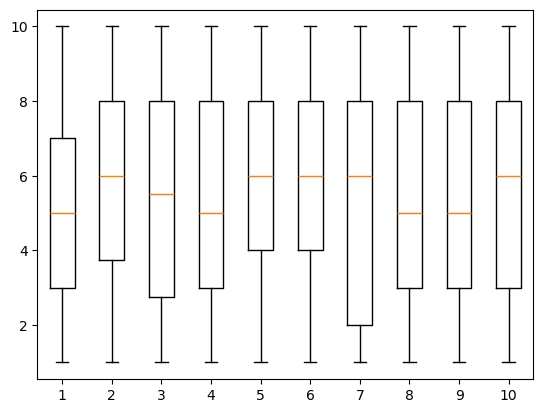

In [41]:
# Checar si hay datos atípicos.
plt.boxplot(df[["Gusto_por_Matematicas","Gusto_por_Lectura","Interes_en_IA", "Habilidad_Habla_Publica", "Pensamiento_Analitico", "Interes_en_Asuntos_Globales", "Habilidad_Resolucion_Problemas", "Promedio_Prepa", "Puntos_Examen_Admision", "Velocidad_Lectura"]])
plt.show()

### Es mejor un arbol de decisión pues queremos ver si podemos predecir la carrera
### Y la carrera es un dato categórico.

In [42]:
df[["Gusto_por_Matematicas","Gusto_por_Lectura","Interes_en_IA", "Habilidad_Habla_Publica", "Pensamiento_Analitico", "Interes_en_Asuntos_Globales", "Habilidad_Resolucion_Problemas", "Promedio_Prepa", "Puntos_Examen_Admision", "Velocidad_Lectura"]].corr()

,Gusto_por_Matematicas,Gusto_por_Lectura,Interes_en_IA,Habilidad_Habla_Publica,Pensamiento_Analitico,Interes_en_Asuntos_Globales,Habilidad_Resolucion_Problemas,Promedio_Prepa,Puntos_Examen_Admision,Velocidad_Lectura
Gusto_por_Matematicas,1.000000,-0.198577,0.057163,0.018017,-0.237044,0.081400,0.006117,0.088896,-0.004273,0.105585
Gusto_por_Lectura,-0.198577,1.000000,-0.067763,0.072656,0.029597,-0.029556,0.107009,-0.032200,0.033447,-0.033278
Interes_en_IA,0.057163,-0.067763,1.000000,-0.252484,-0.160354,-0.115364,-0.057584,-0.040446,0.003713,-0.023933
Habilidad_Habla_Publica,0.018017,0.072656,-0.252484,1.000000,0.064160,0.040456,0.084061,0.002325,-0.065678,0.044464
Pensamiento_Analitico,-0.237044,0.029597,-0.160354,0.064160,1.000000,0.073169,0.002999,-0.035829,0.095023,0.166116
Interes_en_Asuntos_Globales,0.081400,-0.029556,-0.115364,0.040456,0.073169,1.000000,0.038882,0.100951,-0.033675,-0.096844
Habilidad_Resolucion_Problemas,0.006117,0.107009,-0.057584,0.084061,0.002999,0.038882,1.000000,0.043411,0.024144,0.110260
Promedio_Prepa,0.088896,-0.032200,-0.040446,0.002325,-0.035829,0.100951,0.043411,1.000000,-0.077554,-0.108817
Puntos_Examen_Admision,-0.004273,0.033447,0.003713,-0.065678,0.095023,-0.033675,0.024144,-0.077554,1.000000,0.078546
Velocidad_Lectura,0.105585,-0.033278,-0.023933,0.044464,0.166116,-0.096844,0.110260,-0.108817,0.078546,1.000000


### No hay ninguna relación alta entre las columnas, por lo que usaremos todas para nuestras X

In [33]:
# X = df.drop("Carrera", axis = 1)
# Es lo mismo
X = pd.DataFrame(df[["Gusto_por_Matematicas","Gusto_por_Lectura","Interes_en_IA", "Habilidad_Habla_Publica", "Pensamiento_Analitico", "Interes_en_Asuntos_Globales", "Habilidad_Resolucion_Problemas", "Promedio_Prepa", "Puntos_Examen_Admision", "Velocidad_Lectura"]])
y = pd.DataFrame(df["Carrera"])

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

0.5


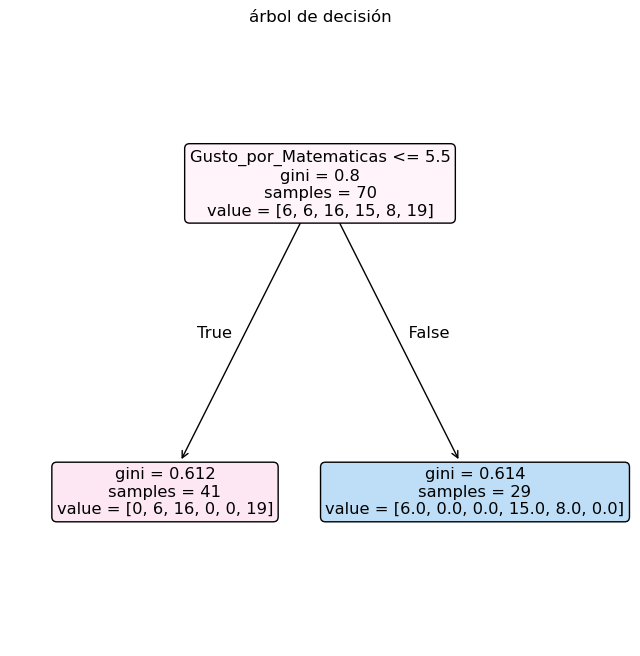

0.7666666666666667


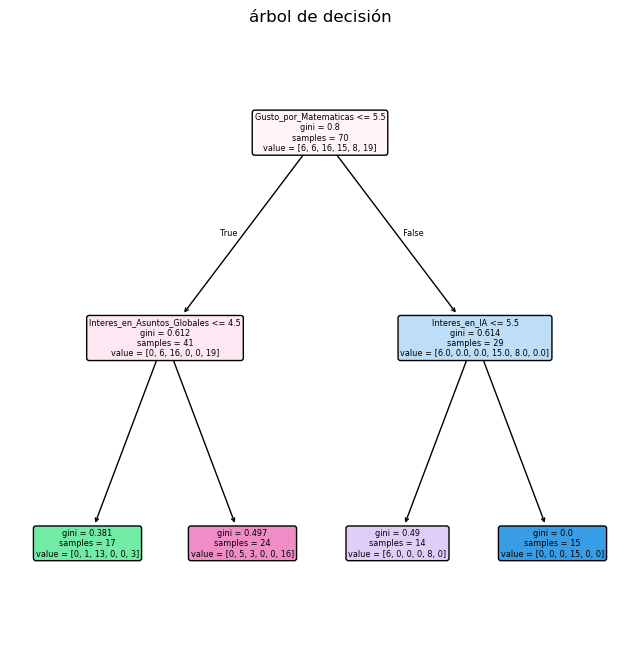

0.8


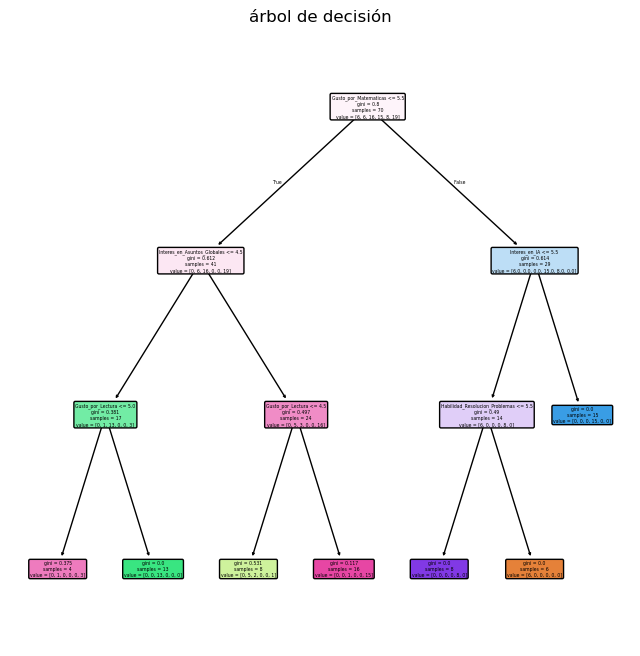

0.8


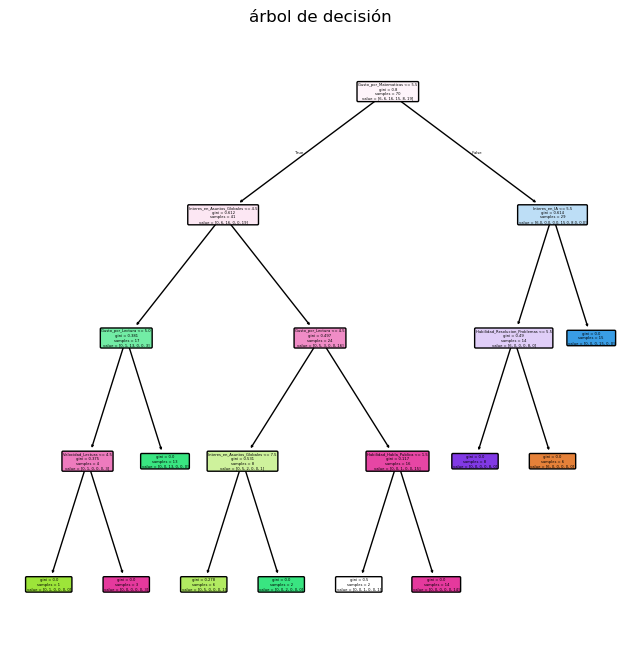

0.7666666666666667


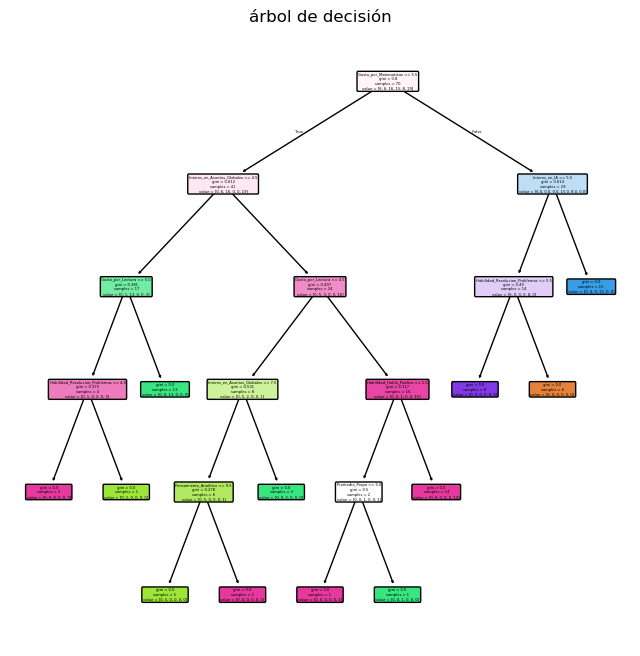

0.8


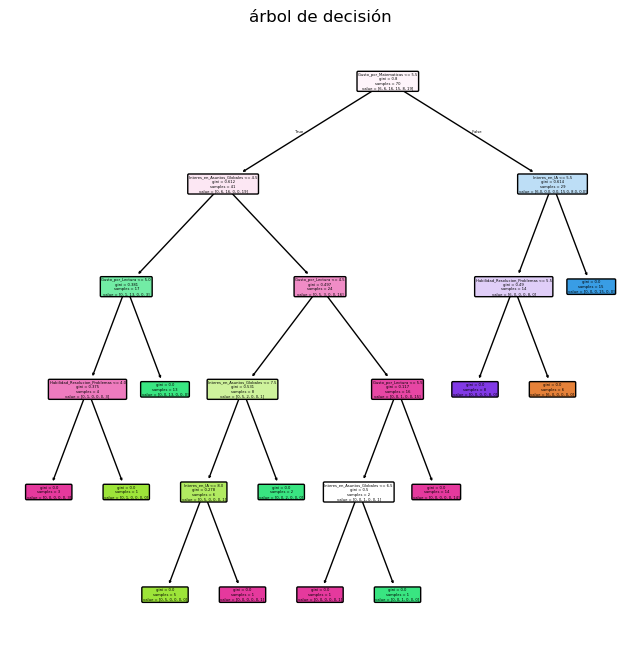

In [48]:
profundidades = (1, 2, 3, 4 ,5, 6)
scores = []
for profundidad in profundidades:
    dtc = tree.DecisionTreeClassifier(max_depth=profundidad)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    print(score)
    scores.append(score)

    plt.figure(figsize = (8,8))
    tree.plot_tree(dtc, feature_names=X.columns, filled=True, rounded=True)
    plt.title("árbol de decisión")
    plt.show()

### Aparentemente por uso de memoria el mejor arbol sería el de 3 de profundidad.
### Pues los demás arboles dan el mismo score.

In [53]:
scores_train = []
for profundidad in profundidades:
    dtc = tree.DecisionTreeClassifier(max_depth=profundidad)
    dtc.fit(X_train, y_train)
    y_pred = dtc.predict(X_train)
    score = accuracy_score(y_train, y_pred)
    scores_train.append(score)

print(scores_train)

[0.4857142857142857, 0.7428571428571429, 0.9285714285714286, 0.9714285714285714, 1.0, 1.0]


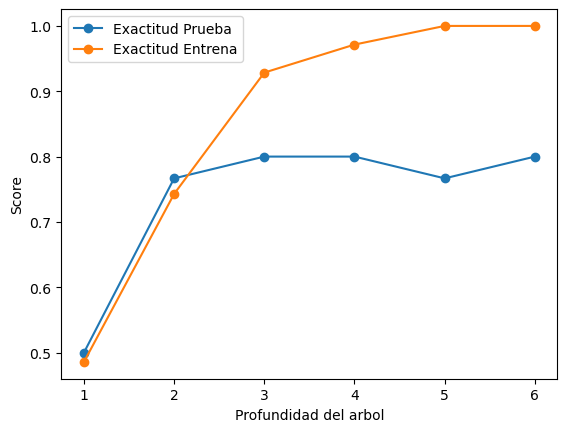

In [54]:
plt.plot(profundidades, scores, label = "Exactitud Prueba", marker = 'o')
plt.plot(profundidades, scores_train, label = "Exactitud Entrena", marker = 'o')

plt.xlabel("Profundidad del arbol")
plt.ylabel("Score")
plt.legend()
plt.show()

In [55]:
# Por como se separa la predicción el mejor modelo es el de profundidad 2.